In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
from train import train_model, evaluate
from mlp import MLP
from data import load_mnist_subset
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt
from utils import reuse_weights, glorot_init

In [ ]:
model = MLP(20)

is_underparam = True
X_train, y_train, X_test, y_test = load_mnist_subset()
y_train_onehot = F.one_hot(y_train, num_classes=10).float()
y_test_onehot = F.one_hot(y_test, num_classes=10).float()

trained_model, losses = train_model(model, X_train, y_train_onehot, y_train, is_underparam)

In [10]:
train_preds = trained_model(X_train).argmax(dim=1)
train_error = (train_preds != y_train).float().mean().item()
train_acc = np.round((1 - train_error)*100, 1)

print(f"Train data acc: {train_acc}")

test_preds = trained_model(X_test).argmax(dim=1)
test_error = (test_preds != y_test).float().mean().item()
test_acc = np.round((1 - test_error)*100, 1)

print(f"Test data acc: {test_acc}")

Train data acc: 96.6
Test data acc: 88.1


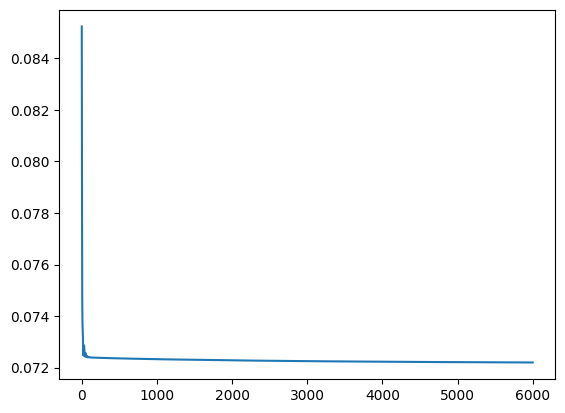

In [8]:
plt.plot(losses)

In [8]:
np.mean((trained_model(X_test) - y_test_onehot).detach().numpy()**2)

np.float32(0.07145557)

In [9]:
evaluate(trained_model, X_train, y_train_onehot, y_train)

(0.6737499833106995, np.float32(0.06939369))

In [10]:
evaluate(trained_model, X_test, y_test_onehot, y_test)

(0.6944000124931335, np.float32(0.07145557))

num epochs run: 6000
first loss: 0.16981613636016846
last loss: 0.08993228524923325


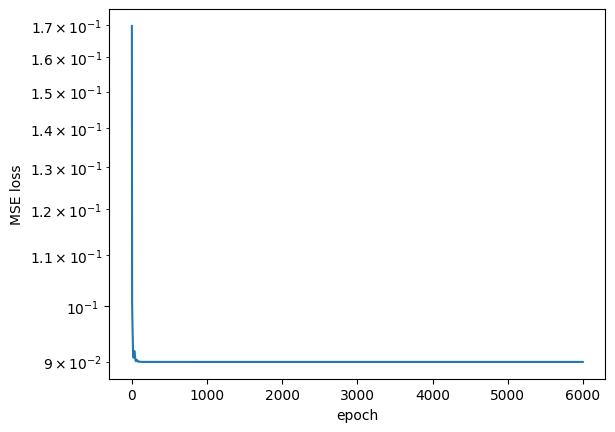

In [3]:
from mlp import MLP
from utils import glorot_init
from data import load_mnist_subset, onehot
from train import train_model
import matplotlib.pyplot as plt

X_train, y_train, X_test, y_test = load_mnist_subset(n=4000, seed=0)
y_train_onehot = onehot(y_train)

model = MLP(5)
glorot_init(model)
_, losses = train_model(model, X_train, y_train_onehot, y_train, is_underparam=True)

print("num epochs run:", len(losses))
print("first loss:", losses[0])
print("last loss:", losses[-1])
plt.plot(losses)
plt.yscale('log')
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()